# Feature Ablation Study

This notebook systematically evaluates the contribution of each feature family to
classification performance. All experiments use the same pipeline, models, and
evaluation strategy — only the feature subset changes.

**Ablation configurations:**

| # | Configuration | Description |
|---|--------------|-------------|
| 1 | MFDFA only | Multifractal features alone (12 features) |
| 2 | MFDFA + OpenSMILE | Multifractal + eGeMAPSv02 |
| 3 | MFDFA + NeuroKit2 | Multifractal + entropy/fractal dims |
| 4 | MFDFA + NeuroKit2 + OpenSMILE | All non-acoustic features |
| 5 | Best of above − Age | Remove age from the best-performing config |

All experiments use:
- Token: `a_n` (sustained /a/ at normal pitch)
- 5-fold `StratifiedGroupKFold` on `speaker_id`
- Same 4 models (LogReg, RandomForest, LightGBM, XGBoost)
- Same disease grouping (Neurological / Structural) and balancing strategy

## 1 — Setup & Imports

In [1]:
import sys
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sys.path.append('..')
from src.features import FeatureOptions, load_feature_tables

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

print('Setup complete.')

Setup complete.


## 2 — Configuration

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

SELECTED_TOKEN = 'a_n'
MIN_SAMPLES_PER_CLASS = 50
MAX_SAMPLES_PER_CLASS = 500
BALANCE_HEALTHY = True
EXCLUDE_OVERLAP_SPEAKERS = False
EXCLUDE_MIXED_BINARY_SPEAKERS = True

N_SPLITS = 5
THRESHOLD_GRID = np.linspace(0.35, 0.65, 11)
BINARY_THRESHOLD_OBJECTIVE = 'accuracy'

TARGET_SOURCE_COL_PREFERENCE = 'pathology_de'
USE_GROUPED_TARGET = True
KEEP_UNMAPPED_LABELS = False

DISEASE_GROUP_MAP = {
    'Morbus Parkinson': 'Neurological',
    'Rekurrensparese': 'Neurological',
    'Spasmodische Dysphonie': 'Neurological',
    'Phonationsknötchen': 'Structural',
    'Stimmlippenpolyp': 'Structural',
    'Laryngitis': 'Structural',
}

COLLINEARITY_THRESHOLD = 0.85

opts = FeatureOptions(
    prefix=Path('..'),
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    balance_healthy=BALANCE_HEALTHY,
    selected_token=SELECTED_TOKEN,
    num_workers=None,
    mfdfa_q_step=0.5,
    mfdfa_num_scales=40,
    target_sample_rate=50000,
)
print('Config ready.')

Config ready.


## 3 — Load Feature Tables

In [3]:
tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

# De-duplicate each table on sample_key
core_df = tables['core'].drop_duplicates(subset=['sample_key']).copy()
multifractal_df = tables['multifractal'].drop_duplicates(subset=['sample_key']).copy()
opensmile_df = tables.get('opensmile', pd.DataFrame())
if not opensmile_df.empty:
    opensmile_df = opensmile_df.drop_duplicates(subset=['sample_key']).copy()
neurokit2_df = tables.get('neurokit2', pd.DataFrame())
if not neurokit2_df.empty:
    neurokit2_df = neurokit2_df.drop_duplicates(subset=['sample_key']).copy()
splits_df = tables.get('splits', pd.DataFrame())
if not splits_df.empty:
    splits_df = splits_df.drop_duplicates(subset=['sample_key']).copy()

# Load age from manifest
manifest_path = Path('..') / 'data' / 'processed' / 'manifests' / 'dataset_manifest.csv'
manifest_dates = pd.read_csv(manifest_path, usecols=['sample_key', 'birth_date', 'recording_date'])
manifest_dates = manifest_dates.drop_duplicates(subset=['sample_key'])

print(f'Core: {core_df.shape}')
print(f'Multifractal: {multifractal_df.shape}')
print(f'OpenSMILE: {opensmile_df.shape}')
print(f'NeuroKit2: {neurokit2_df.shape}')

Core: (1656, 18)
Multifractal: (1656, 17)
OpenSMILE: (1656, 91)
NeuroKit2: (1656, 10)


## 4 — Build Full Dataset (all features merged)

We build one combined DataFrame with *all* feature families, then select subsets
per ablation experiment. This ensures **identical samples and splits** across all runs.

In [4]:
df_full = core_df.copy()
df_full = df_full.merge(multifractal_df, on='sample_key', how='left')
if not opensmile_df.empty:
    df_full = df_full.merge(opensmile_df, on='sample_key', how='left')
if not neurokit2_df.empty:
    df_full = df_full.merge(neurokit2_df, on='sample_key', how='left')
if not splits_df.empty:
    df_full = df_full.merge(splits_df, on='sample_key', how='left')

# Add age
df_full = df_full.merge(manifest_dates, on='sample_key', how='left')
bd = pd.to_datetime(df_full['birth_date'], errors='coerce')
rd = pd.to_datetime(df_full['recording_date'], errors='coerce')
df_full['age'] = ((rd - bd).dt.days / 365.25).round(1)
df_full.drop(columns=['birth_date', 'recording_date'], inplace=True)

# Status filters
for col, val in [('feature_status', ['ok', 'partial_failure']),
                  ('mf_status', ['ok']),
                  ('opensmile_status', ['ok']),
                  ('nk_status', ['ok'])]:
    if col in df_full.columns:
        df_full = df_full[df_full[col].isin(val)].copy()

print(f'Full merged shape: {df_full.shape}')
print(f'Unique speakers: {df_full["speaker_id"].nunique()}')
print(f'Age: mean={df_full["age"].mean():.1f}  missing={df_full["age"].isna().sum()}')

Full merged shape: (1656, 136)
Unique speakers: 1355
Age: mean=41.2  missing=0


## 5 — Build Targets & Apply Filters

In [5]:
df = df_full.copy()

# Build grouped target
raw_target = df[TARGET_SOURCE_COL_PREFERENCE].astype(str).str.strip()
mapped_target = raw_target.map(DISEASE_GROUP_MAP)

# Drop pathological samples not in DISEASE_GROUP_MAP
unmapped_mask = mapped_target.isna() & ~df['is_healthy'].astype(bool)
if unmapped_mask.any():
    dropped = raw_target[unmapped_mask].value_counts().to_dict()
    print(f'Dropping {unmapped_mask.sum()} samples with unmapped pathologies: {dropped}')
    df = df[~unmapped_mask].copy()
    raw_target = raw_target[~unmapped_mask]
    mapped_target = mapped_target[~unmapped_mask]

mapped_target.loc[df['is_healthy'].astype(bool)] = 'healthy'
df['target_label'] = mapped_target.astype(str)
target_col = 'target_label'

# Remove mixed-label speakers
if EXCLUDE_MIXED_BINARY_SPEAKERS and 'speaker_id' in df.columns:
    grp = df.groupby(df['speaker_id'].astype(str))['is_healthy'].nunique()
    bad_speakers = set(grp[grp > 1].index.tolist())
    if bad_speakers:
        removed = int(df['speaker_id'].astype(str).isin(bad_speakers).sum())
        print(f'Removing {removed} mixed-label speaker rows ({len(bad_speakers)} speakers)')
        df = df[~df['speaker_id'].astype(str).isin(bad_speakers)].copy()

# Drop small classes
small_classes = df[target_col].value_counts()[df[target_col].value_counts() < MIN_SAMPLES_PER_CLASS].index.tolist()
if small_classes:
    print(f'Dropping classes with < {MIN_SAMPLES_PER_CLASS} samples: {small_classes}')
    df = df[~df[target_col].isin(small_classes)].copy()

# Re-balance healthy
if BALANCE_HEALTHY:
    n_patho = int((~df['is_healthy'].astype(bool)).sum())
    healthy_mask = df['is_healthy'].astype(bool)
    n_healthy = int(healthy_mask.sum())
    if n_healthy > n_patho:
        drop_n = n_healthy - n_patho
        drop_idx = df[healthy_mask].sample(n=drop_n, random_state=RANDOM_SEED).index
        df = df.drop(drop_idx).copy()
        print(f'Re-balanced healthy: {n_healthy} -> {n_patho} (dropped {drop_n})')

display(df[target_col].value_counts().to_frame('sample_count'))
print(f'\nTotal samples: {len(df)}  |  Unique speakers: {df["speaker_id"].nunique()}')

Dropping 506 samples with unmapped pathologies: {'Hyperfunktionelle Dysphonie': 213, 'Funktionelle Dysphonie': 112, 'Psychogene Dysphonie': 91, 'Reinke Ödem': 68, 'Phonationsknötchen': 17, 'Hypotone Dysphonie': 5}
Removing 4 mixed-label speaker rows (2 speakers)
Re-balanced healthy: 685 -> 461 (dropped 224)


,sample_count
target_label,
healthy,461
Neurological,277
Structural,184



Total samples: 922  |  Unique speakers: 787


## 6 — Define Feature Subsets

Each ablation uses a different subset of feature columns, drawn from the same
filtered DataFrame. The metadata and target columns are excluded from all subsets.

In [6]:
META_COLS = {
    'sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id', 'wav_path',
    'feature_status', 'feature_error', 'acoustic_status', 'acoustic_error',
    'mf_status', 'mf_error', 'opensmile_status', 'opensmile_error',
    'nk_status', 'nk_error', 'mf_num_scales', 'mf_num_q',
    'split', 'split_seed', 'pathology_de', 'pathology_en', target_col, 'is_healthy',
    'is_overlap_speaker', 'is_overlap_speaker_id',
}

# Identify feature columns by prefix / source table
mf_cols = [c for c in df.columns if c.startswith('mf_') and c not in META_COLS]
os_cols = [c for c in df.columns if c.startswith('os_') and c not in META_COLS]
nk_cols = [c for c in df.columns if c.startswith('nk_') and c not in META_COLS]

# "age" and "sex" are standalone columns, not prefixed
extra_numeric = [c for c in ['age'] if c in df.columns]
categorical_cols = [c for c in ['sex'] if c in df.columns]

print(f'MFDFA features:    {len(mf_cols)}')
print(f'OpenSMILE features: {len(os_cols)}')
print(f'NeuroKit2 features: {len(nk_cols)}')
print(f'Extra numeric:     {extra_numeric}')
print(f'Categorical:       {categorical_cols}')

# Define ablation configurations
# Each config: (label, numeric_cols_to_use, include_age)
ABLATIONS = [
    ('MFDFA only',                      mf_cols,                          True),
    ('MFDFA + OpenSMILE',               mf_cols + os_cols,                True),
    ('MFDFA + NeuroKit2',               mf_cols + nk_cols,                True),
    ('MFDFA + NeuroKit2 + OpenSMILE',   mf_cols + nk_cols + os_cols,      True),
]

for label, cols, inc_age in ABLATIONS:
    total = len(cols) + (len(extra_numeric) if inc_age else 0)
    print(f'  {label:40s} → {total} numeric features')

MFDFA features:    12
OpenSMILE features: 88
NeuroKit2 features: 7
Extra numeric:     ['age']
Categorical:       ['sex']
  MFDFA only                               → 13 numeric features
  MFDFA + OpenSMILE                        → 101 numeric features
  MFDFA + NeuroKit2                        → 20 numeric features
  MFDFA + NeuroKit2 + OpenSMILE            → 108 numeric features


## 7 — Evaluation Functions

Same evaluation harness as the main training notebooks: speaker-grouped stratified
K-fold CV with threshold tuning for binary classification.

In [7]:
TREE_MODELS = (RandomForestClassifier, XGBClassifier, LGBMClassifier)


def _build_preprocessors(num_cols, cat_cols):
    """Build tree and linear preprocessors for the given column sets."""
    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    tree_transformers = [('num', 'passthrough', num_cols)]
    if cat_cols:
        tree_transformers.append(('cat', cat_pipe, cat_cols))
    tree_prep = ColumnTransformer(transformers=tree_transformers, remainder='drop').set_output(transform='pandas')

    linear_num_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0.0, add_indicator=True)),
        ('scaler', PowerTransformer(method='yeo-johnson', standardize=True)),
        ('variance', VarianceThreshold(threshold=0.0)),
    ])
    linear_transformers = [('num', linear_num_pipe, num_cols)]
    if cat_cols:
        linear_transformers.append(('cat', cat_pipe, cat_cols))
    linear_prep = ColumnTransformer(transformers=linear_transformers, remainder='drop').set_output(transform='pandas')

    return tree_prep, linear_prep


def _make_pipe(model, tree_prep, linear_prep):
    prep = tree_prep if isinstance(model, TREE_MODELS) else linear_prep
    return Pipeline(steps=[('prep', prep), ('model', model)])


def _make_sample_weights(y_enc):
    classes = np.unique(y_enc)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_enc)
    weight_map = {cls: w for cls, w in zip(classes, weights)}
    return np.array([weight_map[v] for v in y_enc], dtype=float)


def run_binary_cv(model, X, y, groups, tree_prep, linear_prep, n_splits=N_SPLITS):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        pipe = _make_pipe(clone(model), tree_prep, linear_prep)
        pipe.fit(X_tr, y_tr)

        p_tr = pipe.predict_proba(X_tr)[:, 1]
        best_thr, best_score = 0.5, -1.0
        for thr in THRESHOLD_GRID:
            pred_tr = (p_tr >= thr).astype(int)
            score = accuracy_score(y_tr, pred_tr) if BINARY_THRESHOLD_OBJECTIVE == 'accuracy' else balanced_accuracy_score(y_tr, pred_tr)
            if score > best_score:
                best_score, best_thr = score, float(thr)

        pred_te = (pipe.predict_proba(X_te)[:, 1] >= best_thr).astype(int)
        fold_rows.append({
            'fold': fold,
            'accuracy': accuracy_score(y_te, pred_te),
            'balanced_accuracy': balanced_accuracy_score(y_te, pred_te),
            'f1_macro': f1_score(y_te, pred_te, average='macro', zero_division=0),
        })

    fold_df = pd.DataFrame(fold_rows)
    return {
        'accuracy_mean': fold_df['accuracy'].mean(),
        'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
        'f1_macro_mean': fold_df['f1_macro'].mean(),
    }


def run_multiclass_cv(model, X, y, groups, tree_prep, linear_prep, n_splits=N_SPLITS):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    fold_rows = []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        le = LabelEncoder()
        y_tr_enc = le.fit_transform(y_tr.astype(str))
        y_te_enc = le.transform(y_te.astype(str))
        sw = _make_sample_weights(y_tr_enc)

        pipe = _make_pipe(clone(model), tree_prep, linear_prep)
        pipe.fit(X_tr, y_tr_enc, model__sample_weight=sw)
        pred_enc = pipe.predict(X_te)

        fold_rows.append({
            'fold': fold,
            'accuracy': accuracy_score(y_te_enc, pred_enc),
            'balanced_accuracy': balanced_accuracy_score(y_te_enc, pred_enc),
            'f1_macro': f1_score(y_te_enc, pred_enc, average='macro', zero_division=0),
        })

    fold_df = pd.DataFrame(fold_rows)
    return {
        'accuracy_mean': fold_df['accuracy'].mean(),
        'balanced_accuracy_mean': fold_df['balanced_accuracy'].mean(),
        'f1_macro_mean': fold_df['f1_macro'].mean(),
    }


print('Evaluation functions ready.')

Evaluation functions ready.


## 8 — Define Models

In [8]:
binary_models = {
    'LogReg': LogisticRegression(max_iter=3000, class_weight='balanced', C=1.0, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=2,
        class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=800, learning_rate=0.03, num_leaves=63,
        min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=700, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=1.0, reg_lambda=2.0,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='logloss',
    ),
}

multi_models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight='balanced_subsample', random_state=RANDOM_SEED, n_jobs=-1,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1, verbose=-1,
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_alpha=1.0, reg_lambda=2.0,
        random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss',
    ),
}

print(f'Binary models:  {list(binary_models.keys())}')
print(f'Multi models:   {list(multi_models.keys())}')

Binary models:  ['LogReg', 'RandomForest', 'LightGBM', 'XGBoost']
Multi models:   ['RandomForest', 'LightGBM', 'XGBoost']


## 9 — Run Ablation Experiments

For each feature configuration, we:
1. Select the numeric columns for that config
2. Apply collinearity filtering
3. Build preprocessors
4. Run binary and multi-class CV with all models
5. Collect results into summary tables

In [9]:
# Shared targets and groups (identical across all ablations)
y_bin = df['is_healthy'].astype(int).copy()
y_multi = df[target_col].astype(str).copy()
groups = df['speaker_id'].astype(str).copy()

idx_patho = y_bin == 0

all_binary_results = []
all_multi_results = []

for ablation_label, base_cols, include_age in ABLATIONS:
    print(f'\n{"="*60}')
    print(f'ABLATION: {ablation_label}')
    print(f'{"="*60}')

    # Build numeric columns for this ablation
    num_cols = list(base_cols)
    if include_age and extra_numeric:
        num_cols = num_cols + extra_numeric

    # Keep only columns that exist and are numeric
    num_cols = [c for c in num_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

    # Collinearity filtering
    corr_matrix = df[num_cols].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
    collinear_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > COLLINEARITY_THRESHOLD)]
    if collinear_to_drop:
        num_cols = [c for c in num_cols if c not in collinear_to_drop]
        print(f'  Dropped {len(collinear_to_drop)} collinear features (|r| > {COLLINEARITY_THRESHOLD})')

    print(f'  Features: {len(num_cols)} numeric + {len(categorical_cols)} categorical')

    X_abl = df[num_cols + categorical_cols].copy()
    tree_prep, linear_prep = _build_preprocessors(num_cols, categorical_cols)

    # --- Binary CV ---
    print(f'  Running binary CV...')
    for model_name, model in binary_models.items():
        summ = run_binary_cv(model, X_abl, y_bin, groups, tree_prep, linear_prep)
        all_binary_results.append({'config': ablation_label, 'model': model_name, **summ})

    # --- Multi-class CV (pathological only) ---
    print(f'  Running multi-class CV...')
    X_patho = X_abl[idx_patho]
    y_patho = y_multi[idx_patho]
    g_patho = groups[idx_patho]
    for model_name, model in multi_models.items():
        summ = run_multiclass_cv(model, X_patho, y_patho, g_patho, tree_prep, linear_prep)
        all_multi_results.append({'config': ablation_label, 'model': model_name, **summ})

    print(f'  Done.')

print(f'\n{"="*60}')
print('All ablations complete.')


ABLATION: MFDFA only
  Dropped 8 collinear features (|r| > 0.85)
  Features: 5 numeric + 1 categorical
  Running binary CV...
  Running multi-class CV...
  Done.

ABLATION: MFDFA + OpenSMILE
  Dropped 28 collinear features (|r| > 0.85)
  Features: 73 numeric + 1 categorical
  Running binary CV...
  Running multi-class CV...
  Done.

ABLATION: MFDFA + NeuroKit2
  Dropped 9 collinear features (|r| > 0.85)
  Features: 11 numeric + 1 categorical
  Running binary CV...
  Running multi-class CV...
  Done.

ABLATION: MFDFA + NeuroKit2 + OpenSMILE
  Dropped 30 collinear features (|r| > 0.85)
  Features: 78 numeric + 1 categorical
  Running binary CV...
  Running multi-class CV...
  Done.

All ablations complete.


## 10 — Determine Best Config & Run Without Age

In [10]:
# Find the best ablation config by binary f1_macro_mean (best model per config)
bin_df = pd.DataFrame(all_binary_results)
best_per_config = bin_df.groupby('config')['f1_macro_mean'].max().sort_values(ascending=False)
best_config_label = best_per_config.index[0]

print(f'Best binary config: "{best_config_label}" (F1 = {best_per_config.iloc[0]:.4f})')
print(f'\nAll configs ranked by best binary F1:')
display(best_per_config.to_frame('best_f1_macro').reset_index())

# Look up which base_cols correspond to the best config
best_base_cols = None
for label, cols, _ in ABLATIONS:
    if label == best_config_label:
        best_base_cols = cols
        break

# --- Run the winner WITHOUT age ---
no_age_label = f'{best_config_label} − Age'
print(f'\n{"="*60}')
print(f'ABLATION: {no_age_label}')
print(f'{"="*60}')

num_cols_no_age = [c for c in best_base_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
# Explicitly exclude age
num_cols_no_age = [c for c in num_cols_no_age if c != 'age']

# Collinearity filtering
corr_matrix = df[num_cols_no_age].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
collinear_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > COLLINEARITY_THRESHOLD)]
if collinear_to_drop:
    num_cols_no_age = [c for c in num_cols_no_age if c not in collinear_to_drop]
    print(f'  Dropped {len(collinear_to_drop)} collinear features')

print(f'  Features: {len(num_cols_no_age)} numeric + {len(categorical_cols)} categorical (no age)')

X_no_age = df[num_cols_no_age + categorical_cols].copy()
tree_prep_na, linear_prep_na = _build_preprocessors(num_cols_no_age, categorical_cols)

print(f'  Running binary CV...')
for model_name, model in binary_models.items():
    summ = run_binary_cv(model, X_no_age, y_bin, groups, tree_prep_na, linear_prep_na)
    all_binary_results.append({'config': no_age_label, 'model': model_name, **summ})

print(f'  Running multi-class CV...')
X_patho_na = X_no_age[idx_patho]
for model_name, model in multi_models.items():
    summ = run_multiclass_cv(model, X_patho_na, y_patho, g_patho, tree_prep_na, linear_prep_na)
    all_multi_results.append({'config': no_age_label, 'model': model_name, **summ})

print(f'  Done.')

Best binary config: "MFDFA + OpenSMILE" (F1 = 0.8784)

All configs ranked by best binary F1:


,config,best_f1_macro
0,MFDFA + OpenSMILE,0.878408
1,MFDFA + NeuroKit2 + OpenSMILE,0.876004
2,MFDFA + NeuroKit2,0.867423
3,MFDFA only,0.865935



ABLATION: MFDFA + OpenSMILE − Age
  Dropped 28 collinear features
  Features: 72 numeric + 1 categorical (no age)
  Running binary CV...
  Running multi-class CV...
  Done.


## 11 — Results: Binary Classification (Healthy vs Pathological)

In [11]:
bin_df = pd.DataFrame(all_binary_results)

# Best model per config
best_binary = (
    bin_df
    .sort_values('f1_macro_mean', ascending=False)
    .drop_duplicates(subset='config', keep='first')
    .reset_index(drop=True)
)

print('Best model per configuration (Binary — Healthy vs Pathological):')
display(best_binary[['config', 'model', 'accuracy_mean', 'balanced_accuracy_mean', 'f1_macro_mean']])

print('\nFull results:')
display(
    bin_df
    .sort_values(['config', 'f1_macro_mean'], ascending=[True, False])
    .reset_index(drop=True)
)

Best model per configuration (Binary — Healthy vs Pathological):


,config,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,MFDFA + OpenSMILE,LightGBM,0.878555,0.878623,0.878408
1,MFDFA + NeuroKit2 + OpenSMILE,XGBoost,0.876392,0.876496,0.876004
2,MFDFA + NeuroKit2,LogReg,0.867703,0.867824,0.867423
3,MFDFA only,LogReg,0.866639,0.866819,0.865935
4,MFDFA + OpenSMILE − Age,LightGBM,0.751657,0.751718,0.749138



Full results:


,config,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,MFDFA + NeuroKit2,LogReg,0.867703,0.867824,0.867423
1,MFDFA + NeuroKit2,XGBoost,0.854647,0.854722,0.854337
2,MFDFA + NeuroKit2,RandomForest,0.853613,0.853752,0.853032
3,MFDFA + NeuroKit2,LightGBM,0.844888,0.844963,0.844426
4,MFDFA + NeuroKit2 + OpenSMILE,XGBoost,0.876392,0.876496,0.876004
5,MFDFA + NeuroKit2 + OpenSMILE,LightGBM,0.868796,0.868841,0.868646
6,MFDFA + NeuroKit2 + OpenSMILE,LogReg,0.861222,0.861314,0.860912
7,MFDFA + NeuroKit2 + OpenSMILE,RandomForest,0.855793,0.855961,0.854979
8,MFDFA + OpenSMILE,LightGBM,0.878555,0.878623,0.878408
9,MFDFA + OpenSMILE,XGBoost,0.877479,0.877571,0.877158


## 12 — Results: Multi-class Classification (Neurological vs Structural)

In [12]:
multi_df = pd.DataFrame(all_multi_results)

# Best model per config
best_multi = (
    multi_df
    .sort_values('f1_macro_mean', ascending=False)
    .drop_duplicates(subset='config', keep='first')
    .reset_index(drop=True)
)

print('Best model per configuration (Multi-class — Pathology Groups):')
display(best_multi[['config', 'model', 'accuracy_mean', 'balanced_accuracy_mean', 'f1_macro_mean']])

print('\nFull results:')
display(
    multi_df
    .sort_values(['config', 'f1_macro_mean'], ascending=[True, False])
    .reset_index(drop=True)
)

Best model per configuration (Multi-class — Pathology Groups):


,config,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,MFDFA + NeuroKit2 + OpenSMILE,RandomForest,0.661066,0.633797,0.635919
1,MFDFA only,RandomForest,0.652605,0.634343,0.635164
2,MFDFA + OpenSMILE,RandomForest,0.647926,0.625561,0.626846
3,MFDFA + NeuroKit2,RandomForest,0.646343,0.620930,0.622675
4,MFDFA + OpenSMILE − Age,RandomForest,0.645823,0.619144,0.619488



Full results:


,config,model,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
0,MFDFA + NeuroKit2,RandomForest,0.646343,0.620930,0.622675
1,MFDFA + NeuroKit2,XGBoost,0.607302,0.595893,0.593687
2,MFDFA + NeuroKit2,LightGBM,0.572752,0.561497,0.559455
3,MFDFA + NeuroKit2 + OpenSMILE,RandomForest,0.661066,0.633797,0.635919
4,MFDFA + NeuroKit2 + OpenSMILE,LightGBM,0.624223,0.618561,0.614620
5,MFDFA + NeuroKit2 + OpenSMILE,XGBoost,0.611225,0.603605,0.600397
6,MFDFA + OpenSMILE,RandomForest,0.647926,0.625561,0.626846
7,MFDFA + OpenSMILE,LightGBM,0.632825,0.622758,0.619610
8,MFDFA + OpenSMILE,XGBoost,0.628666,0.623662,0.619107
9,MFDFA + OpenSMILE − Age,RandomForest,0.645823,0.619144,0.619488


## 13 — Visualisation: Ablation Comparison

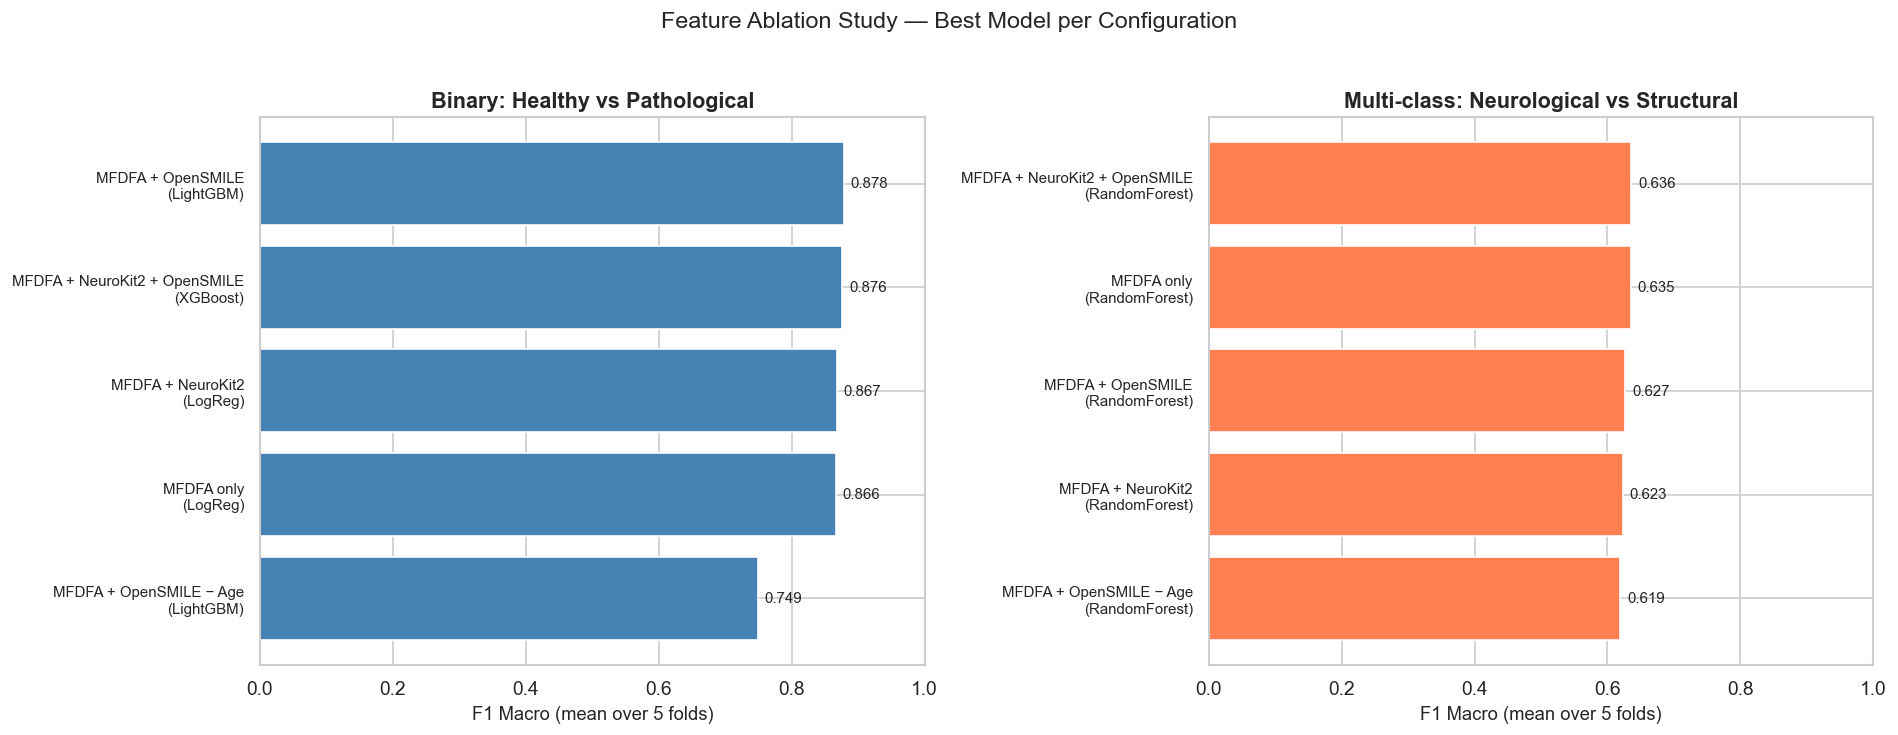

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Binary bar chart ---
ax = axes[0]
plot_data = best_binary.sort_values('f1_macro_mean', ascending=True)
bars = ax.barh(range(len(plot_data)), plot_data['f1_macro_mean'], color='steelblue', edgecolor='white')
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([f"{row['config']}\n({row['model']})" for _, row in plot_data.iterrows()], fontsize=9)
ax.set_xlabel('F1 Macro (mean over 5 folds)', fontsize=11)
ax.set_title('Binary: Healthy vs Pathological', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, plot_data['f1_macro_mean']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)

# --- Multi-class bar chart ---
ax = axes[1]
plot_data = best_multi.sort_values('f1_macro_mean', ascending=True)
bars = ax.barh(range(len(plot_data)), plot_data['f1_macro_mean'], color='coral', edgecolor='white')
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels([f"{row['config']}\n({row['model']})" for _, row in plot_data.iterrows()], fontsize=9)
ax.set_xlabel('F1 Macro (mean over 5 folds)', fontsize=11)
ax.set_title('Multi-class: Neurological vs Structural', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, plot_data['f1_macro_mean']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=9)

fig.suptitle('Feature Ablation Study — Best Model per Configuration', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 14 — Age Impact Analysis

Age Impact on Binary Classification (MFDFA + OpenSMILE):


,With Age,Without Age,Δ F1
model,,,
LogReg,0.8674,0.7292,0.1382
RandomForest,0.8576,0.7392,0.1183
LightGBM,0.8784,0.7491,0.1293
XGBoost,0.8772,0.7438,0.1333



Age Impact on Multi-class Classification (MFDFA + OpenSMILE):


,With Age,Without Age,Δ F1
model,,,
RandomForest,0.6268,0.6195,0.0074
LightGBM,0.6196,0.6014,0.0182
XGBoost,0.6191,0.6038,0.0153


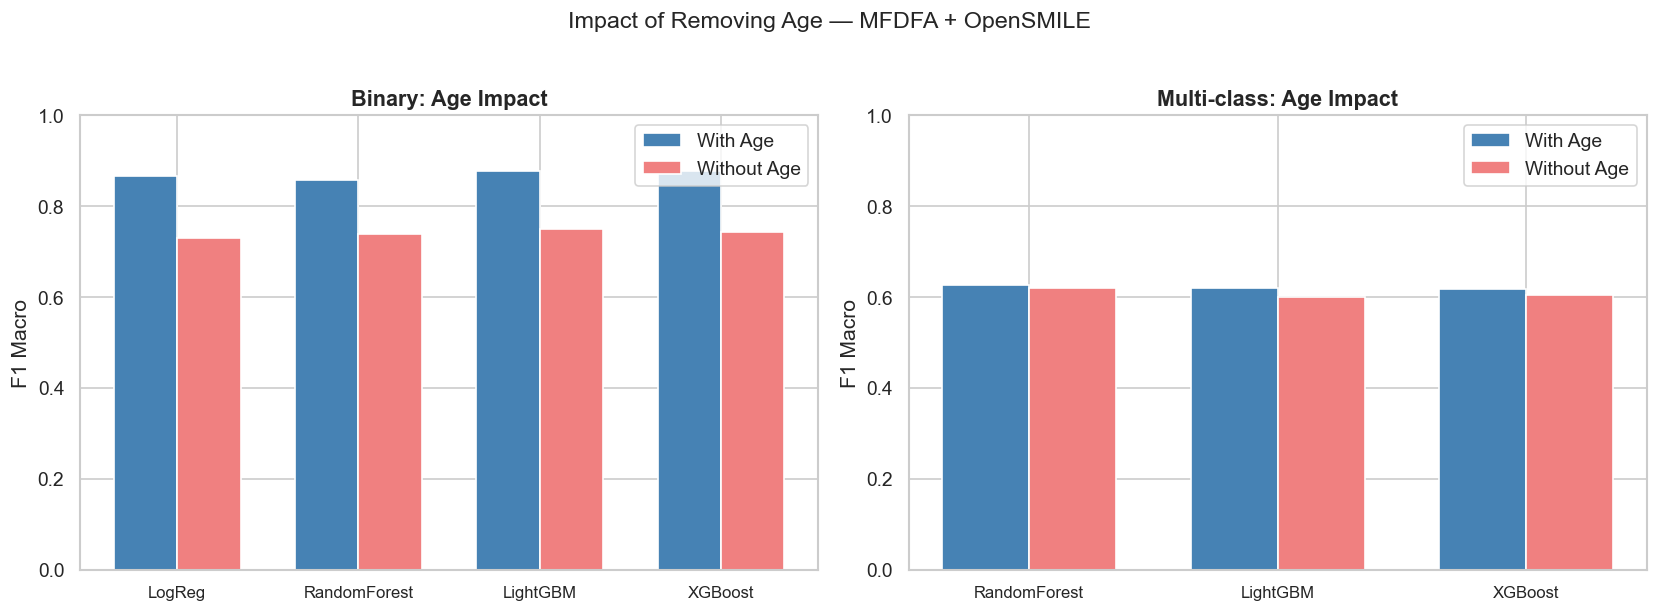

In [14]:
# Compare the best config with and without age
no_age_label = f'{best_config_label} − Age'

bin_with = bin_df[bin_df['config'] == best_config_label].set_index('model')['f1_macro_mean']
bin_without = bin_df[bin_df['config'] == no_age_label].set_index('model')['f1_macro_mean']

multi_with = multi_df[multi_df['config'] == best_config_label].set_index('model')['f1_macro_mean']
multi_without = multi_df[multi_df['config'] == no_age_label].set_index('model')['f1_macro_mean']

# Binary comparison
age_impact_bin = pd.DataFrame({
    'With Age': bin_with,
    'Without Age': bin_without,
    'Δ F1': bin_with - bin_without,
}).round(4)

print(f'Age Impact on Binary Classification ({best_config_label}):')
display(age_impact_bin)

# Multi-class comparison
age_impact_multi = pd.DataFrame({
    'With Age': multi_with,
    'Without Age': multi_without,
    'Δ F1': multi_with - multi_without,
}).round(4)

print(f'\nAge Impact on Multi-class Classification ({best_config_label}):')
display(age_impact_multi)

# Visualise
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(age_impact_bin))
w = 0.35
ax1.bar(x - w/2, age_impact_bin['With Age'], w, label='With Age', color='steelblue')
ax1.bar(x + w/2, age_impact_bin['Without Age'], w, label='Without Age', color='lightcoral')
ax1.set_xticks(x)
ax1.set_xticklabels(age_impact_bin.index, fontsize=10)
ax1.set_ylabel('F1 Macro')
ax1.set_title('Binary: Age Impact', fontsize=13, fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 1.0)

x = np.arange(len(age_impact_multi))
ax2.bar(x - w/2, age_impact_multi['With Age'], w, label='With Age', color='steelblue')
ax2.bar(x + w/2, age_impact_multi['Without Age'], w, label='Without Age', color='lightcoral')
ax2.set_xticks(x)
ax2.set_xticklabels(age_impact_multi.index, fontsize=10)
ax2.set_ylabel('F1 Macro')
ax2.set_title('Multi-class: Age Impact', fontsize=13, fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 1.0)

fig.suptitle(f'Impact of Removing Age — {best_config_label}', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 15 — Summary

In [16]:
print('='*70)
print('FEATURE ABLATION STUDY — SUMMARY')
print('='*70)

print('\n--- Binary Classification (Healthy vs Pathological) ---')
summary_bin = best_binary[['config', 'model', 'f1_macro_mean']].copy()
# Add the no-age row only if not already present
if no_age_label not in summary_bin['config'].values:
    no_age_bin = bin_df[bin_df['config'] == no_age_label].sort_values('f1_macro_mean', ascending=False).iloc[0]
    summary_bin = pd.concat([summary_bin, pd.DataFrame([{
        'config': no_age_label,
        'model': no_age_bin['model'],
        'f1_macro_mean': no_age_bin['f1_macro_mean'],
    }])], ignore_index=True)
summary_bin = summary_bin.sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)
display(summary_bin)

print('\n--- Multi-class Classification (Neurological vs Structural) ---')
summary_multi = best_multi[['config', 'model', 'f1_macro_mean']].copy()
if no_age_label not in summary_multi['config'].values:
    no_age_multi = multi_df[multi_df['config'] == no_age_label].sort_values('f1_macro_mean', ascending=False).iloc[0]
    summary_multi = pd.concat([summary_multi, pd.DataFrame([{
        'config': no_age_label,
        'model': no_age_multi['model'],
        'f1_macro_mean': no_age_multi['f1_macro_mean'],
    }])], ignore_index=True)
summary_multi = summary_multi.sort_values('f1_macro_mean', ascending=False).reset_index(drop=True)
display(summary_multi)

# Key takeaway
print('\n--- Key Findings ---')
best_bin_f1 = summary_bin.iloc[0]['f1_macro_mean']
best_bin_cfg = summary_bin.iloc[0]['config']
mfdfa_only_f1 = summary_bin[summary_bin['config'] == 'MFDFA only']['f1_macro_mean'].values[0]
print(f'  Best binary config: {best_bin_cfg} (F1 = {best_bin_f1:.4f})')
print(f'  MFDFA-only baseline: F1 = {mfdfa_only_f1:.4f}')
print(f'  Improvement from adding features: +{best_bin_f1 - mfdfa_only_f1:.4f} F1')

age_delta = age_impact_bin['Δ F1'].mean()
print(f'  Age contribution (mean Δ across models): {age_delta:+.4f} F1')

FEATURE ABLATION STUDY — SUMMARY

--- Binary Classification (Healthy vs Pathological) ---


,config,model,f1_macro_mean
0,MFDFA + OpenSMILE,LightGBM,0.878408
1,MFDFA + NeuroKit2 + OpenSMILE,XGBoost,0.876004
2,MFDFA + NeuroKit2,LogReg,0.867423
3,MFDFA only,LogReg,0.865935
4,MFDFA + OpenSMILE − Age,LightGBM,0.749138



--- Multi-class Classification (Neurological vs Structural) ---


,config,model,f1_macro_mean
0,MFDFA + NeuroKit2 + OpenSMILE,RandomForest,0.635919
1,MFDFA only,RandomForest,0.635164
2,MFDFA + OpenSMILE,RandomForest,0.626846
3,MFDFA + NeuroKit2,RandomForest,0.622675
4,MFDFA + OpenSMILE − Age,RandomForest,0.619488



--- Key Findings ---
  Best binary config: MFDFA + OpenSMILE (F1 = 0.8784)
  MFDFA-only baseline: F1 = 0.8659
  Improvement from adding features: +0.0125 F1
  Age contribution (mean Δ across models): +0.1298 F1
